# Plot Per-Class Results from Saved CSV (No Black/White)

This notebook loads previously saved per-class classification results and creates publication-quality plots.
Results are from prototype-based classification experiments excluding black and white images.

**MODIFICATION**: This version uses results from tests that excluded black and white colors to focus on chromatic color discrimination.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Path setup
REPO_ROOT = r'C:\Users\jbats\Projects\NTU-Synthetic'
RESULTS_DIR = os.path.join(REPO_ROOT, 'PatrickProject', 'Chart_Generation')

# Load the summary CSV for no-black-white results
summary_file = os.path.join(RESULTS_DIR, 'class_noblackwhite_perclass_summary.csv')
if os.path.exists(summary_file):
    summary_df = pd.read_csv(summary_file)
    print(f"Loaded data from {summary_file}")
    print(f"Shape: {summary_df.shape}")
    print("\nFirst few rows:")
    print(summary_df.head())
    print(f"\nModels in data: {summary_df['model'].unique()}")
    print(f"Number of unique classes: {summary_df['class'].nunique()}")
else:
    print(f"File not found: {summary_file}")
    print("Please run the class experiment (no black/white) first to generate the data.")

Loaded data from C:\Users\jbats\Projects\NTU-Synthetic\PatrickProject\Chart_Generation\class_noblackwhite_perclass_summary.csv
Shape: (134, 8)

First few rows:
          model          class  mean_accuracy       std        se      ci95  \
0  cvcl-resnext         abacus       0.917333  0.007572  0.004372  0.008568   
1  cvcl-resnext          apple       0.864000  0.002000  0.001155  0.002263   
2  cvcl-resnext            axe       0.866000  0.026000  0.015011  0.029422   
3  cvcl-resnext  babushkadolls       0.883333  0.032146  0.018559  0.036376   
4  cvcl-resnext          bagel       0.784000  0.027495  0.015875  0.031114   

   n_seeds  total_trials  
0        3          1500  
1        3          1500  
2        3          1500  
3        3          1500  
4        3          1500  

Models in data: ['cvcl-resnext' 'clip-res']
Number of unique classes: 67


In [2]:
# Reconstruct stats_results from CSV
stats_results = {}
models = summary_df['model'].unique()

for model in models:
    stats_results[model] = {}
    model_data = summary_df[summary_df['model'] == model]
    
    for _, row in model_data.iterrows():
        stats_results[model][row['class']] = {
            'mean': row['mean_accuracy'],
            'std': row['std'] if 'std' in row else 0,
            'se': row['se'] if 'se' in row else 0,
            'ci95': row['ci95'] if 'ci95' in row else 0,
            'n_samples': row['n_seeds'] if 'n_seeds' in row else 1,
            'total_trials': row['total_trials'] if 'total_trials' in row else 500
        }

models_to_test = list(models)
print(f"Models found: {models_to_test}")
print(f"Number of classes: {len(stats_results[models_to_test[0]])}")

# Calculate overall means for display
for model in models_to_test:
    all_means = [stats['mean'] * 100 for stats in stats_results[model].values()]
    print(f"\n{model} overall mean: {np.mean(all_means):.1f}%")

Models found: ['cvcl-resnext', 'clip-res']
Number of classes: 67

cvcl-resnext overall mean: 78.0%

clip-res overall mean: 92.8%


C:\Users\jbats\AppData\Local\Temp\ipykernel_42476\278230788.py:132: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\jbats\AppData\Local\Temp\ipykernel_42476\278230788.py:154: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


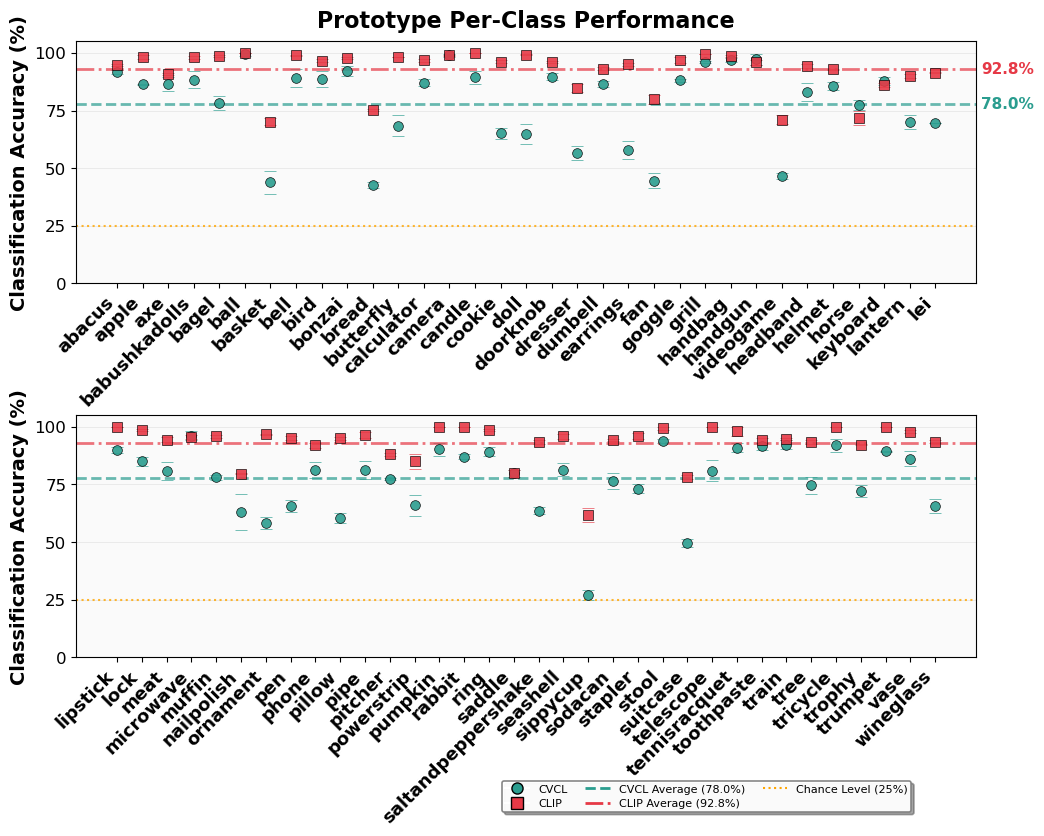


Saved plots from CSV data to:
  - C:\Users\jbats\Projects\NTU-Synthetic\PatrickProject\Chart_Generation\class_noblackwhite_perclass_from_csv.png
  - C:\Users\jbats\Projects\NTU-Synthetic\PatrickProject\Chart_Generation\class_noblackwhite_perclass_from_csv.pdf


In [4]:
# Create publication-quality visualization with two subplots
fig = plt.figure(figsize=(10, 8))  # smaller figure (was (14, 11))

# Create subplots with space for legend in between
ax1 = plt.subplot2grid((20, 1), (0, 0), rowspan=8)
ax2 = plt.subplot2grid((20, 1), (12, 0), rowspan=8)

# Prepare data for plotting
classes = sorted(list(stats_results[models_to_test[0]].keys()))

# Split classes into two groups
mid_point = len(classes) // 2
classes_first_half = classes[:mid_point]
classes_second_half = classes[mid_point:]

# Define colors and styles
colors = {
    'cvcl-resnext': '#2a9d8f',  # Teal/green color for CVCL
    'clip-res': '#e63946'       # Red color for CLIP
}
markers = {
    'cvcl-resnext': 'o',
    'clip-res': 's'             # Square for CLIP
}
avg_line_styles = {
    'cvcl-resnext': '--',
    'clip-res': '-.'
}

# Short display labels for the legend
short_labels = {
    'cvcl-resnext': 'CVCL',
    'clip-res': 'CLIP'
}

# Store legend elements globally
legend_elements = []

# Function to plot data on an axis
def plot_on_axis(ax, class_subset, is_first=False):
    x_pos = np.arange(len(class_subset))
    
    # Plot each model
    for model_name in models_to_test:
        means = [stats_results[model_name][cls]['mean'] * 100 for cls in class_subset]
        errors = [stats_results[model_name][cls]['ci95'] * 100 for cls in class_subset]
        
        ax.errorbar(x_pos, means, yerr=errors, 
                    label=None,
                    color=colors[model_name],
                    marker=markers[model_name],
                    markersize=7,
                    linewidth=0,
                    capsize=4,
                    capthick=1.5,
                    alpha=0.9,
                    markeredgecolor='black',
                    markeredgewidth=0.5)
    
    # Add chance line
    ax.axhline(y=25, color='#ffa500', linestyle=':', alpha=0.8, linewidth=1.5)
    
    # Calculate and add average lines
    all_classes_means = {}
    for model_name in models_to_test:
        all_means = [stats_results[model_name][cls]['mean'] * 100 for cls in classes]
        all_classes_means[model_name] = np.mean(all_means)
    
    for model_name in models_to_test:
        avg_performance = all_classes_means[model_name]
        ax.axhline(y=avg_performance, 
                   color=colors[model_name], 
                   linestyle=avg_line_styles[model_name], 
                   alpha=0.7, 
                   linewidth=2)
        
        if is_first:
            ax.text(len(class_subset) + 0.8, avg_performance, 
                    f'{avg_performance:.1f}%', 
                    fontsize=11,             # larger avg value label
                    color=colors[model_name], 
                    va='center',
                    fontweight='bold')
    
    # Formatting
    ax.set_ylabel('Classification Accuracy (%)', fontsize=14, fontweight='bold')  # bigger
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['videogame' if lbl == 'handheldgame' else lbl for lbl in class_subset],
                   rotation=45, ha='right', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.tick_params(axis='y', labelsize=12)  # make y tick labels readable on smaller fig
    ax.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.set_facecolor('#fafafa')
    
    # Create legend elements (only once)
    global legend_elements
    if is_first:
        from matplotlib.lines import Line2D
        legend_elements = []
        
        for model_name in models_to_test:
            legend_elements.append(
                Line2D([0], [0], marker=markers[model_name], color='w', 
                       markerfacecolor=colors[model_name], markeredgecolor='black',
                       markersize=8, label=short_labels[model_name])
            )
        
        for model_name in models_to_test:
            avg_val = all_classes_means[model_name]
            legend_elements.append(
                Line2D([0], [0], color=colors[model_name], 
                       linestyle=avg_line_styles[model_name], linewidth=2,
                       label=f'{model_name.upper().split("-")[0]} Average ({avg_val:.1f}%)')
            )
        
        legend_elements.append(
            Line2D([0], [0], color='#ffa500', linestyle=':', linewidth=1.5,
                   label='Chance Level (25%)')
        )

# Plot both halves
plot_on_axis(ax1, classes_first_half, is_first=True)
ax1.set_title('Prototype Per-Class Performance', 
              fontsize=16, fontweight='bold', pad=10)  # bigger

plot_on_axis(ax2, classes_second_half, is_first=False)
# Remove the xlabel - no "Target Category" label

# --- Legend at the bottom ---
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.18, top=0.95, left=0.08, right=0.98)  # make room at bottom for legend

legend = fig.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.5, -0.02),   # position below the bottom subplot
    ncol=3,
    fontsize=8,                  # legend text size
    frameon=True,
    fancybox=True,
    shadow=True,
    framealpha=0.95,
    borderpad=0.3,
    labelspacing=0.4,
    handlelength=2.2,
    columnspacing=1.6
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('gray')
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.18, top=0.95, left=0.08, right=0.98)

# Save plots
png_path = os.path.join(RESULTS_DIR, 'class_noblackwhite_perclass_from_csv.png')
pdf_path = os.path.join(RESULTS_DIR, 'class_noblackwhite_perclass_from_csv.pdf')

plt.savefig(png_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(pdf_path, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nSaved plots from CSV data to:")
print(f"  - {png_path}")
print(f"  - {pdf_path}")

In [ ]:
# Additional analysis: Compare with original results
original_summary_file = os.path.join(RESULTS_DIR, 'class_perclass_summary.csv')
if os.path.exists(original_summary_file):
    original_df = pd.read_csv(original_summary_file)
    
    print("\n=== Comparison: Original vs No Black/White ===")
    print(f"Original dataset classes: {original_df['class'].nunique()}")
    print(f"No black/white classes: {summary_df['class'].nunique()}")
    
    # Compare overall performance
    for model in models_to_test:
        original_mean = original_df[original_df['model'] == model]['mean_accuracy'].mean() * 100
        noblackwhite_mean = summary_df[summary_df['model'] == model]['mean_accuracy'].mean() * 100
        difference = noblackwhite_mean - original_mean
        
        print(f"\n{model}:")
        print(f"  Original: {original_mean:.1f}%")
        print(f"  No Black/White: {noblackwhite_mean:.1f}%")
        print(f"  Difference: {difference:+.1f}%")
    
    # Create comparison plot
    fig, ax = plt.subplots(figsize=(8, 6))
    
    models_short = ['CVCL', 'CLIP']
    original_means = [original_df[original_df['model'] == model]['mean_accuracy'].mean() * 100 for model in models_to_test]
    noblackwhite_means = [summary_df[summary_df['model'] == model]['mean_accuracy'].mean() * 100 for model in models_to_test]
    
    x = np.arange(len(models_short))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, original_means, width, label='Original Dataset', color='lightblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, noblackwhite_means, width, label='No Black/White', color='lightcoral', alpha=0.8)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Classification Accuracy (%)', fontsize=12, fontweight='bold')
    ax.set_title('Overall Performance: Original vs No Black/White', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_short)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 100)
    
    plt.tight_layout()
    comparison_path = os.path.join(RESULTS_DIR, 'class_comparison_original_vs_noblackwhite.png')
    plt.savefig(comparison_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"\nSaved comparison plot to: {comparison_path}")
else:
    print(f"\nOriginal results file not found: {original_summary_file}")
    print("Cannot create comparison analysis.")